# Исследовательский анализ на датасет RFSD
## Промежуточная аттестация 2.
### Выполнила: Дина Яковлева
#### Ссылка на Colab: https://colab.research.google.com/drive/1Vw54OfI8b5E_CjFTSzvqFvyuwM_M4x_6?usp=sharing

#1 Установим необходимые пакеты для загрузки данных с github и обработки данных

In [ ]:
pip install datasets
pip install --upgrade huggingface-hub datasets
pip uninstall -y httpx httpcore
pip install httpx httpcore
pip install polars

#2 Произведём загрузку датасета и обработку по именам, выберем 20 колонок

In [ ]:
from datasets import load_dataset
import polars as pl
import pandas as pd
import random

# Загрузим датасет (сабсет для "обучения" (train)), но так как он тяжёлый, обрежем чать данных
RFSD = load_dataset('irlspbru/RFSD', split='train', streaming=True)  #
# Перемешиваем поток «на лету» с помощью буфера, загрузим первые 1 млн строк
#Здесь можно подобрать более подхоядщий метод для выбора строк, а не случайный (зависит от цели исследования)

shuffled_stream = RFSD.shuffle(buffer_size=1000_000, seed=random.randint(0, 1000000))
#Берем случаёные 1000 элементов 'на лету' из предвыборки в 1 млн строк с помощью рандомайзера
limited_stream = shuffled_stream.take(1000)

# Превращаем отфильтрованный поток в список, затем в pandas dataframe для анализа
list_data = list(limited_stream)
df_init = pd.DataFrame(list_data)

#поменяем заголовки колонок c технических на "объясняющие"

renaming_df = pl.read_csv('https://raw.githubusercontent.com/irlcode/RFSD/main/aux_data/descriptive_names_dict.csv')
mapping_dict = dict(zip(renaming_df['original'], renaming_df['descriptive']))
df_init = df_init.rename(columns=mapping_dict)
df=df_init

# Для воспроизводимости оставляем 20 колонок (признаков) +2 колонки (ИНН и регион для понимания какая компания где).
# Данный набор колонок показывает профиль организации, факт наличия отчетности и ее ключевые финансовые результаты для дальнейшего выполнения задания

selected_columns = [
    "inn", "region","age", "financial", "filed", "imputed", "simplified",
    "articulated", "totals_adjustment", "outlier", "lon", "lat",
    "B_fixed_assets", "B_current_assets", "B_inventories",
    "B_accounts_receivable", "B_cash_equivalents", "B_total_equity",
    "B_assets", "B_liab", "PL_revenue", "PL_net_profit"
]

df = df[selected_columns]


In [ ]:
#посмотрим кол-во строк (должно быть 1000) и колонок (должно быть 20+2)
df.shape

#Посмотрим первые 10 строк, убедимся, что города загрузились не по алфавиту, а названия колонок изменены
df.head(10)

,inn,region,age,financial,filed,imputed,simplified,articulated,totals_adjustment,outlier,lon,lat,B_fixed_assets,B_current_assets,B_inventories,B_accounts_receivable,B_cash_equivalents,B_total_equity,B_assets,B_liab,PL_revenue,PL_net_profit
0,0278034718,bashkortostan,17.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1831117923,udmurtia,6.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2223005567,altai terr.,20.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1020017357,karelia,2.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1660008382,tatarstan,13.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1639041228,tatarstan,3.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1101136151,komi,4.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,None,None,NaN,NaN,NaN,NaN,NaN,-315.0,57.0,57.0,NaN,NaN
7,1513034180,north ossetia,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2011883810,chechnya,10.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1658122320,tatarstan,2.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Установим пакеты и настроим их для расчёта статистики и графиков
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 25)

## Подготовка данных

Числовые финансовые показатели преобразуем в числовой формат. Пустые значения сохраняются как `NaN`: это важно, поскольку пропуск в датасете RFSD часто означает отсутствие соответствующей строки отчетности, а не обязательно нулевое значение.

In [ ]:
numeric_columns = [c for c in selected_columns if c not in ["financial"]]
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Размер данных:", df.shape)
print("Количество колонок:", len(df.columns))
#Посмотрим на данные после обработки
df.head(10)

Размер данных: (1000, 22)
Количество колонок: 22


C:\Users\Dina\AppData\Local\Temp/ipykernel_9516/2179185186.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.to_numeric(df[col], errors="coerce")


,inn,region,age,financial,filed,imputed,simplified,articulated,totals_adjustment,outlier,lon,lat,B_fixed_assets,B_current_assets,B_inventories,B_accounts_receivable,B_cash_equivalents,B_total_equity,B_assets,B_liab,PL_revenue,PL_net_profit
0,1658216787,NaN,3.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,49.143611,55.835018,NaN,6923.0,NaN,3706.0,3217.0,299.0,6923.0,6923.0,12324.0,290.0
1,326483233,NaN,13.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,107.760704,51.876588,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN
2,1627017301,NaN,4.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,52.043921,55.755375,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2311328119,NaN,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,38.977240,45.035153,NaN,4683.0,2046.0,2580.0,57.0,-152.0,4683.0,4683.0,2492.0,2310.0
4,2311303844,NaN,2.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,38.940248,45.102229,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN
5,1660263400,NaN,6.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,49.195236,55.807892,NaN,146.0,NaN,NaN,1.0,-1253.0,146.0,146.0,NaN,NaN
6,2308001650,NaN,34.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,38.977240,45.035153,5080.0,10425.0,1091.0,816.0,8518.0,NaN,24526.0,24526.0,NaN,NaN
7,307031295,NaN,19.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,103.297959,50.393624,1402.0,7263.0,6688.0,456.0,119.0,-12769.0,8665.0,8665.0,69.0,-2537.0
8,277929032,NaN,4.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,56.085178,54.835256,443.0,91319.0,29562.0,59691.0,708.0,2773.0,91762.0,91762.0,74164.0,882.0
9,1326224569,NaN,9.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,45.195188,54.181922,NaN,3877.0,NaN,3430.0,447.0,743.0,3877.0,3877.0,7347.0,89.0


## 1. Описательная статистика

In [ ]:
# удалим колонку региона при транспонировании т к для статистики она нам не понадобится
description = df.describe(include="all").T.drop('region', axis=0)
description["missing"] = df.isna().sum()
description["missing_pct"] = (df.isna().mean() * 100).round(2)
description

,count,mean,std,min,25%,50%,75%,max,missing,missing_pct
inn,1000.0,1.438289e+09,7.385721e+08,1.010132e+08,7.160118e+08,1.655176e+09,2.130212e+09,2.348044e+09,0,0.0
age,1000.0,9.155000e+00,7.674234e+00,0.000000e+00,3.000000e+00,7.000000e+00,1.400000e+01,5.700000e+01,0,0.0
financial,1000.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0.0
filed,1000.0,6.610000e-01,4.736067e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0,0.0
imputed,1000.0,2.200000e-02,1.467567e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0,0.0
simplified,683.0,5.534407e-01,4.975002e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,317,31.7
articulated,683.0,9.663250e-01,1.805233e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,317,31.7
totals_adjustment,683.0,8.740849e-01,3.319968e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,317,31.7
outlier,1000.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0.0
lon,991.0,5.661275e+01,2.114913e+01,3.022295e+01,4.468211e+01,4.923170e+01,5.599123e+01,1.492790e+02,9,0.9


**Промежуточный вывод:** В датасете одновременно представлены признаки существования и отчетности организаций, возраст компаний и финансовые показатели. Финансовые колонки содержат много пропусков, что связано с тем, что часть организаций не подавала финансовую отчетность. Средние значения денежных показателей могут быть существенно выше медианных: это типичный признак наличия выбросов (в т.ч крупные компании).

## 2. Гистограммы и выбросы

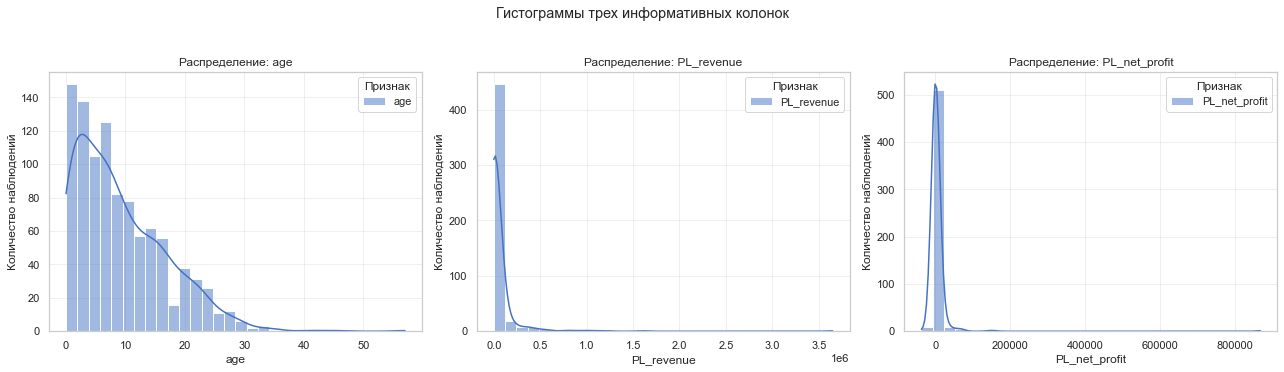

In [ ]:
# Построим гистограммы для признаков: возраст, выручка и чистый доход
hist_columns = ["age", "PL_revenue", "PL_net_profit"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, hist_columns):
    values = df[col].dropna()
    sns.histplot(values, bins=30, kde=True, ax=ax, color="#4472C4", label=col)
    ax.set_title(f"Распределение: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Количество наблюдений")
    ax.legend(title="Признак")
    ax.grid(True, alpha=.3)
plt.suptitle("Гистограммы трех информативных колонок", y=1.03)
plt.tight_layout()
plt.show()

**Интерпретация гистограмм:**
Возраст организаций обычно распределен более однозначно, чем финансовые показатели.
Мы видим, что в нашей выборке больше "молодых компаний", скорее всего для более качественного анализа необходимо разбивать компании по возрасту, т.к. они могут находится на разных жизненных циклах организации.
Выручка и чистая прибыль имеют длинные хвосты справа: несколько крупных организаций значительно превосходят типичный уровень. Для более корректного анализа и сравнения компании также следует разбивать на кластеры по выручке.
Отрицательные значения чистой прибыли являются экономически осмысленными и отражают убыток, поэтому их нельзя автоматически считать ошибками. Эти компании также могут быть выделены в отдельную группу.

In [ ]:
# ПОсмотрим на статистику выбросов
def outlier_summary(series):
    x = series.dropna()
    q1, q3 = x.quantile([.25, .75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (x < lower) | (x > upper)
    return pd.Series({"n": len(x), "q1": q1, "median": x.median(), "q3": q3, "lower_bound": lower, "upper_bound": upper, "outliers": int(mask.sum()), "outlier_pct": round(mask.mean()*100, 2)})

outlier_table = pd.DataFrame({c: outlier_summary(df[c]) for c in hist_columns}).T
outlier_table

,n,q1,median,q3,lower_bound,upper_bound,outliers,outlier_pct
age,1000.0,3.00,7.0,14.00,-13.5,30.5,9.0,0.90
PL_revenue,490.0,1195.75,6142.0,30871.25,-43317.5,75384.5,72.0,14.69
PL_net_profit,535.0,0.00,87.0,1052.00,-1578.0,2630.0,121.0,22.62


**Интерпретация:** Выбросы в колонке возраст могут связаны с ошибкой ввода или вычесления. Если таковых немного и они незначимы для нас, можем их удалить из датасета. Если не можем их удалить, то необходим провести доп анализа таких аномалий.
Выбросы финансовых показателей следует интерпретировать как потенциально крупные предприятия или необычные финансовые результаты и не удалять без дополнительной проверки. Возможно, они показывают нам отдельный паттерн.

## 3. Матрица корреляции

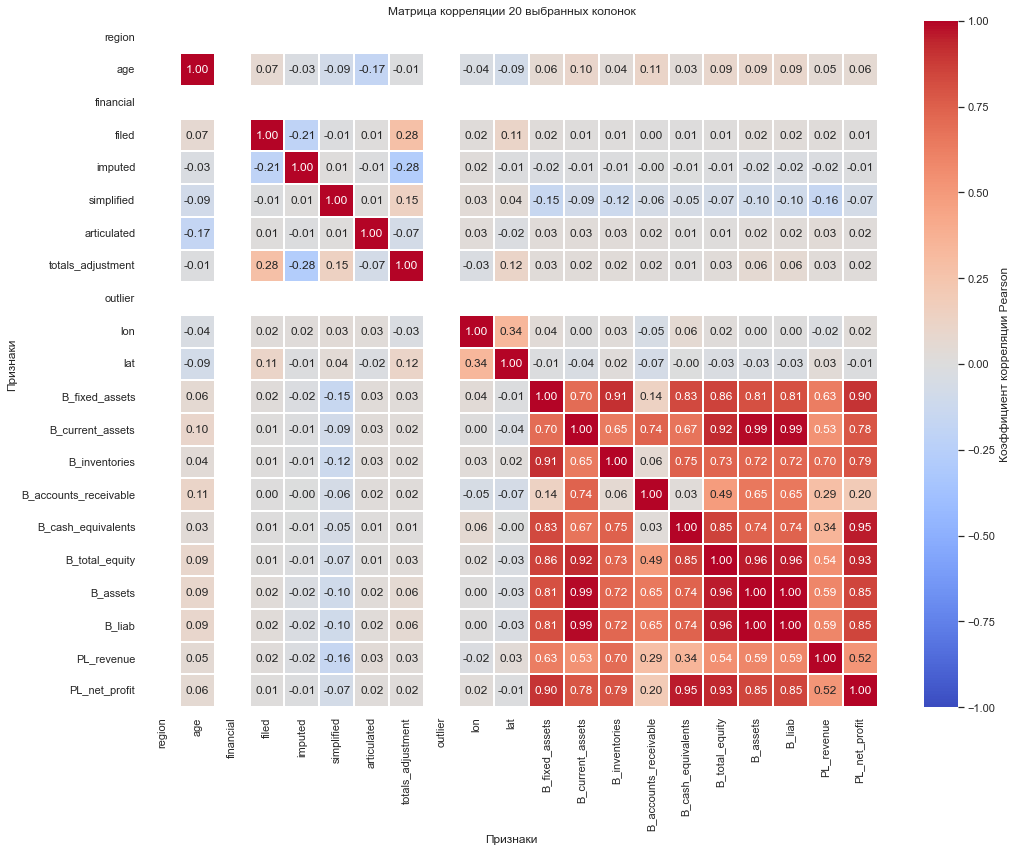

In [ ]:
# Построим матрицу корреляций
numeric_df = df.select_dtypes(include="number")
numeric_df = numeric_df.drop('inn', axis = 1)
corr = numeric_df.corr(method="pearson")
plt.figure(figsize=(15, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f", linewidths=.4, cbar_kws={"label": "Коэффициент корреляции Pearson"})
plt.title("Матрица корреляции 20 выбранных колонок")
plt.xlabel("Признаки")
plt.ylabel("Признаки")
plt.tight_layout()
plt.show()

In [ ]:
# Посчитаем корреляции между парами признаков
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().sort_values(key=lambda x: x.abs(), ascending=False)
# Отфильтруем пары только с высокой корреляцией >= 70%
high_corr = pairs[ pairs.abs() >= 0.70 ]
high_corr.head(15).to_frame("correlation")

correlation
B_assets           B_liab                 1.000000
B_current_assets   B_assets               0.986367
                   B_liab                 0.986367
B_total_equity     B_assets               0.957385
                   B_liab                 0.957385
B_cash_equivalents PL_net_profit          0.954763
B_total_equity     PL_net_profit          0.931434
B_current_assets   B_total_equity         0.922923
B_fixed_assets     B_inventories          0.911867
                   PL_net_profit          0.902591
                   B_total_equity         0.859132
B_cash_equivalents B_total_equity         0.853444
B_liab             PL_net_profit          0.848365
B_assets           PL_net_profit          0.848365
B_fixed_assets     B_cash_equivalents     0.833964

**Интерпретация матрицы:** Наиболее высокие корреляции ожидаются между агрегированными бухгалтерскими показателями: `B_assets` и компонентами активов. Особенно сильная связь активов с отдельными их составляющими объясняется структурной формулой баланса: общий показатель включает соответствующие компоненты (Итоговый собственный капитал (Total Equity) — это чистая стоимость компании, равная разнице между всеми ее активами (Total Assets) и долгами (Total Liabilities)).
Также между `PL_net_profit` и долгами/активами, чистой стоимостью наблюдается высокая связь. Это обусловлено тем, что прибыль увеличивает собственный капитал и укрепляет баланс компании. Рост активов требует финансирования, которое идет либо за счет долга, либо за счет накопленной чистой прибыли.
Высокая корреляция между чистой прибылью и денежными эквивалентами (cash equivalents) объясняетс, как чистая прибыль превращается в реальные деньги и их эквиваленты на счетах (отражено в  Cash Flow Statement)


## 4. Scatter plot

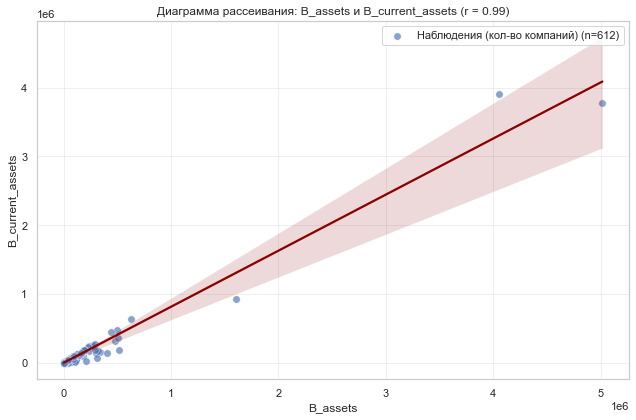

Выбранная пара: B_assets B_current_assets корреляция: 0.986


In [ ]:
# Выберем три пары, затем отобразим пару с самой высокой корреляцией (коэффициент корреляции Пирсона)
# В данном случае метод выбора пары для отображения был выбран по максимальной корреляции, возможно для исследования следует выбрать другую пару, если задан конекретны вопрос для анализа
candidate_pairs = [("B_assets", "B_current_assets"), ("PL_revenue", "PL_net_profit"), ("B_assets", "PL_revenue")]

valid_pairs = [(x, y, abs(corr.loc[x, y])) for x, y in candidate_pairs if x in corr and y in corr]
if valid_pairs:
    x_col, y_col, r = max(valid_pairs, key=lambda t: t[2])
    plot_df = df[[x_col, y_col]].dropna()
    plt.figure(figsize=(9, 6))
    sns.scatterplot(data=plot_df, x=x_col, y=y_col, alpha=.65, s=55, label=f"Наблюдения (кол-во компаний) (n={len(plot_df)})")
    sns.regplot(data=plot_df, x=x_col, y=y_col, scatter=False, color="darkred", line_kws={"label": "Линейный тренд"})
    plt.title(f"Диаграмма рассеивания: {x_col} и {y_col} (r = {r:.2f})")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.legend()
    plt.grid(True, alpha=.3)
    plt.tight_layout()
    plt.show()
    print("Выбранная пара:", x_col, y_col, "корреляция:", round(r, 3))

**Интерпретация scatter plot:** Облако точек должно демонстрировать общий восходящий тренд для наиболее коррелирующей пары. Отдельные удаленные точки соответствуют крупным организациям и одновременно являются потенциальными выбросами, сильно влияющими на коэффициент корредяции Пирсона.

Показатели Assets (совокупные активы) и Current Assets (оборотные активы) связаны жесткой математической и экономическо-структурной зависимостью: текущие активы являются частью общего объема активов компании. Их корреляция в динамике обычно сильная и положительная, так как при росте бизнеса растут и те, и другие.
Формула: Общие активы состоят из оборотных (текущих) и внеоборотных активов
Assets = Current Assets + Non-current Assets

## 5. Итоговые выводы

1. Финансовые показатели распределены несимметрично: медиана существенно устойчивее среднего значения, поскольку несколько крупных компаний (выбросов) формируют длинный правый хвост. Медиана же помогает нивелировать влияние выбросов.
2. В данных присутствуют пропуски в финансовых строках. Это связано с отсутствием отчетности от компаний и является важной особенностью данных RFSD, поэтому пропуски не следует заменять нулем. Эти компании можно выделить в отдельный пул для исследования, возможно, есть какой-то паттерн, среди тех, кто не раскрывает отчёность.
3. Наиболее высокие корреляции наблюдаются у агрегированных балансовых показателей и их составляющих. Это объясняется бухгалтерской структурой баланса, а не независимым причинным влиянием одного показателя на другой.
4. Отрицательные значения  чистой прибыли (`PL_net_profit`) представляют собой интересные кейся для изучения: они отражают убыток. Их нужно анализировать отдельно от технических ошибок и экстремальных значений.
5. Для дальнейшего анализа финансовых распределений целесообразно использовать логарифмическую шкалу `log1p` для неотрицательных показателей или робастные статистики, а также рассматривать компании с финансовой отчетностью отдельно от нефайлеров.

## 6. Дополнительная проверка показателей

In [ ]:
# рассчитаем  четыре показатлея по выборке из 1000 строк
# Посмотри наблюдения о пропусках, нефайлерах и убыточности

# Оставляем только непустые значения для корректных расчетов
revenue = df["PL_revenue"].dropna()
net_profit = df["PL_net_profit"].dropna()

# Рассчитываем показатели
share_with_revenue = df["PL_revenue"].notna().mean() * 100
share_with_net_profit = df["PL_net_profit"].notna().mean() * 100
share_negative_net_profit = (net_profit < 0).mean() * 100
share_zero_revenue = (revenue == 0).mean() * 100

# Формируем таблицу показателей
interesting_details = pd.Series({
    "Доля компаний с доступной выручкой, %": round(share_with_revenue, 2),
    "Доля компаний с доступной чистой прибылью, %": round(share_with_net_profit, 2),
    "Доля убыточных среди компаний с указанной чистой прибылью, %": round(share_negative_net_profit, 2),
    "Доля компаний с нулевой выручкой среди компаний с указанной выручкой, %": round(share_zero_revenue, 2),
})

# Вывод таблицы
display(interesting_details.to_frame(name="Значение"))

,Значение
"Доля компаний с доступной выручкой, %",49.00
"Доля компаний с доступной чистой прибылью, %",53.50
"Доля убыточных среди компаний с указанной чистой прибылью, %",24.30
"Доля компаний с нулевой выручкой среди компаний с указанной выручкой, %",9.18


**Интерпретация доп проверки:**

**1)** Всего околы половины компаний из выборки (1000 компаний) подали данные о вручке, чистой прибыли;

**2)** Около четверти компаний с данными о чистой прибыли - убыточны;

**3)** Около 9% компаний - нулёвок (нулевая выручка).